In [1]:
from pathlib import Path
import xarray as xr
import utils
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import umap
from sklearn.datasets import load_digits

/data/keeling/a/ianpark3/miniconda3/envs/ThesisTest/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
folder_path = 'Model_Data/CompleteData'

In [3]:
ds = utils.consolidate_data(folder_path)

In [6]:
ds_cleaned = ds.dropna(dim = 'frame_number', how = 'any')
ds_cleaned = ds_cleaned.where(ds_cleaned['max_wind'] >= 17, drop = True)
ds_cleaned = ds_cleaned.where(ds_cleaned['center_lat'] > 0, drop = True)

In [7]:
ds_cleaned

<xarray.Dataset> Size: 9GB
Dimensions:          (frame_number: 429, levels: 3, angle: 720, radius: 501)
Coordinates:
  * frame_number     (frame_number) int64 3kB 0 3 4 5 7 ... 595 596 597 598 599
    valid_time       (frame_number) datetime64[ns] 3kB 2023-08-08T12:00:00 .....
  * levels           (levels) object 24B 'sfc' '700' '200'
  * angle            (angle) float64 6kB 0.0 0.5 1.0 1.5 ... 358.5 359.0 359.5
  * radius           (radius) float64 4kB 0.0 0.5 1.0 1.5 ... 249.0 249.5 250.0
Data variables:
    frame_link       (frame_number, levels) object 10kB 'https://noaa-nws-haf...
    center_pressure  (frame_number, levels) float32 5kB 957.1 957.1 ... 974.0
    max_wind         (frame_number, levels) float32 5kB 68.55 68.55 ... 41.45
    storm_heading    (frame_number, levels) float64 10kB 267.0 267.0 ... 329.1
    gh               (levels, frame_number, angle, radius) float32 2GB 66.69 ...
    rh               (levels, frame_number, angle, radius) float32 2GB 95.7 ....
    t                (levels, frame_number, angle, radius) float32 2GB 299.8 ...
    u                (levels, frame_number, angle, radius) float32 2GB -6.1 ....
    v                (levels, frame_number, angle, radius) float32 2GB 0.3 .....
    center_lat       (levels, frame_number) float64 10kB 11.86 21.8 ... 20.11
    center_lon       (levels, frame_number) float64 10kB 205.9 245.7 ... 125.3
Attributes:
    history:   Created on 2026-03-22
    Overview:  Data originally obtained from the HAFS Repository (https://reg...

In [8]:
normalized_data_gh_sfc = utils.standard_data_normalizer(ds_cleaned['gh'].isel(levels = 0))
normalized_data_t_sfc = utils.standard_data_normalizer(ds_cleaned['t'].isel(levels = 0))
normalized_data_rh_sfc = utils.standard_data_normalizer(ds_cleaned['rh'].isel(levels = 0))
normalized_data_gh_700 = utils.standard_data_normalizer(ds_cleaned['gh'].isel(levels = 1))
normalized_data_t_700 = utils.standard_data_normalizer(ds_cleaned['t'].isel(levels = 1))
normalized_data_rh_700 = utils.standard_data_normalizer(ds_cleaned['rh'].isel(levels = 1))
normalized_data_gh_200 = utils.standard_data_normalizer(ds_cleaned['gh'].isel(levels = 2))
normalized_data_t_200 = utils.standard_data_normalizer(ds_cleaned['t'].isel(levels = 2))
normalized_data_rh_200 = utils.standard_data_normalizer(ds_cleaned['rh'].isel(levels = 2))


In [11]:
combined_700 = np.stack((
                          normalized_data_gh_700, normalized_data_t_700, normalized_data_rh_700,
                          ), 
                          axis = 0).reshape(429, 3 * 720 * 501)

In [12]:
heights_700 = np.stack(normalized_data_gh_700,axis = 0).reshape(429, 1 * 720 * 501)

In [25]:
reducer3 = umap.UMAP(n_components = 2, n_neighbors = 3, random_state = 42, init = 'pca')
embedding_Full700_n3 = reducer3.fit_transform(combined_700)
embedding_GH700_n3 = reducer3.fit_transform(heights_700)

reducer5 = umap.UMAP(n_components = 2, n_neighbors = 5, random_state = 42, init = 'pca')
embedding_Full700_n5 = reducer5.fit_transform(combined_700)
embedding_GH700_n5 = reducer5.fit_transform(heights_700)

reducer15 = umap.UMAP(n_components = 2, n_neighbors = 15, random_state = 42, init = 'pca')
embedding_Full700_n15 = reducer15.fit_transform(combined_700)
embedding_GH700_n15 = reducer15.fit_transform(heights_700)

reducer10 = umap.UMAP(n_components = 2, n_neighbors = 10, random_state = 42, init = 'pca')
embedding_Full700_n10 = reducer10.fit_transform(combined_700)
embedding_GH700_n10 = reducer10.fit_transform(heights_700)

reducer20 = umap.UMAP(n_components = 2, n_neighbors = 20, random_state = 42, init = 'pca')
embedding_Full700_n20 = reducer20.fit_transform(combined_700)
embedding_GH700_n20 = reducer20.fit_transform(heights_700)


/data/keeling/a/ianpark3/miniconda3/envs/ThesisTest/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/data/keeling/a/ianpark3/miniconda3/envs/ThesisTest/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/data/keeling/a/ianpark3/miniconda3/envs/ThesisTest/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/data/keeling/a/ianpark3/miniconda3/envs/ThesisTest/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/data/keeling/a/ianpark3/miniconda3/envs/ThesisTest/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Us

In [26]:
mslp = ds_cleaned['center_pressure'].values[:,0]
max_winds = ds_cleaned['max_wind'].values[:,0]

Text(0.5, 0.98, 'Comparison of UMAP reductions on HAFS 700mb GPH Model Output\n Data was filtered for winds over 17 m/s and Northern Hemisphere Storms.')

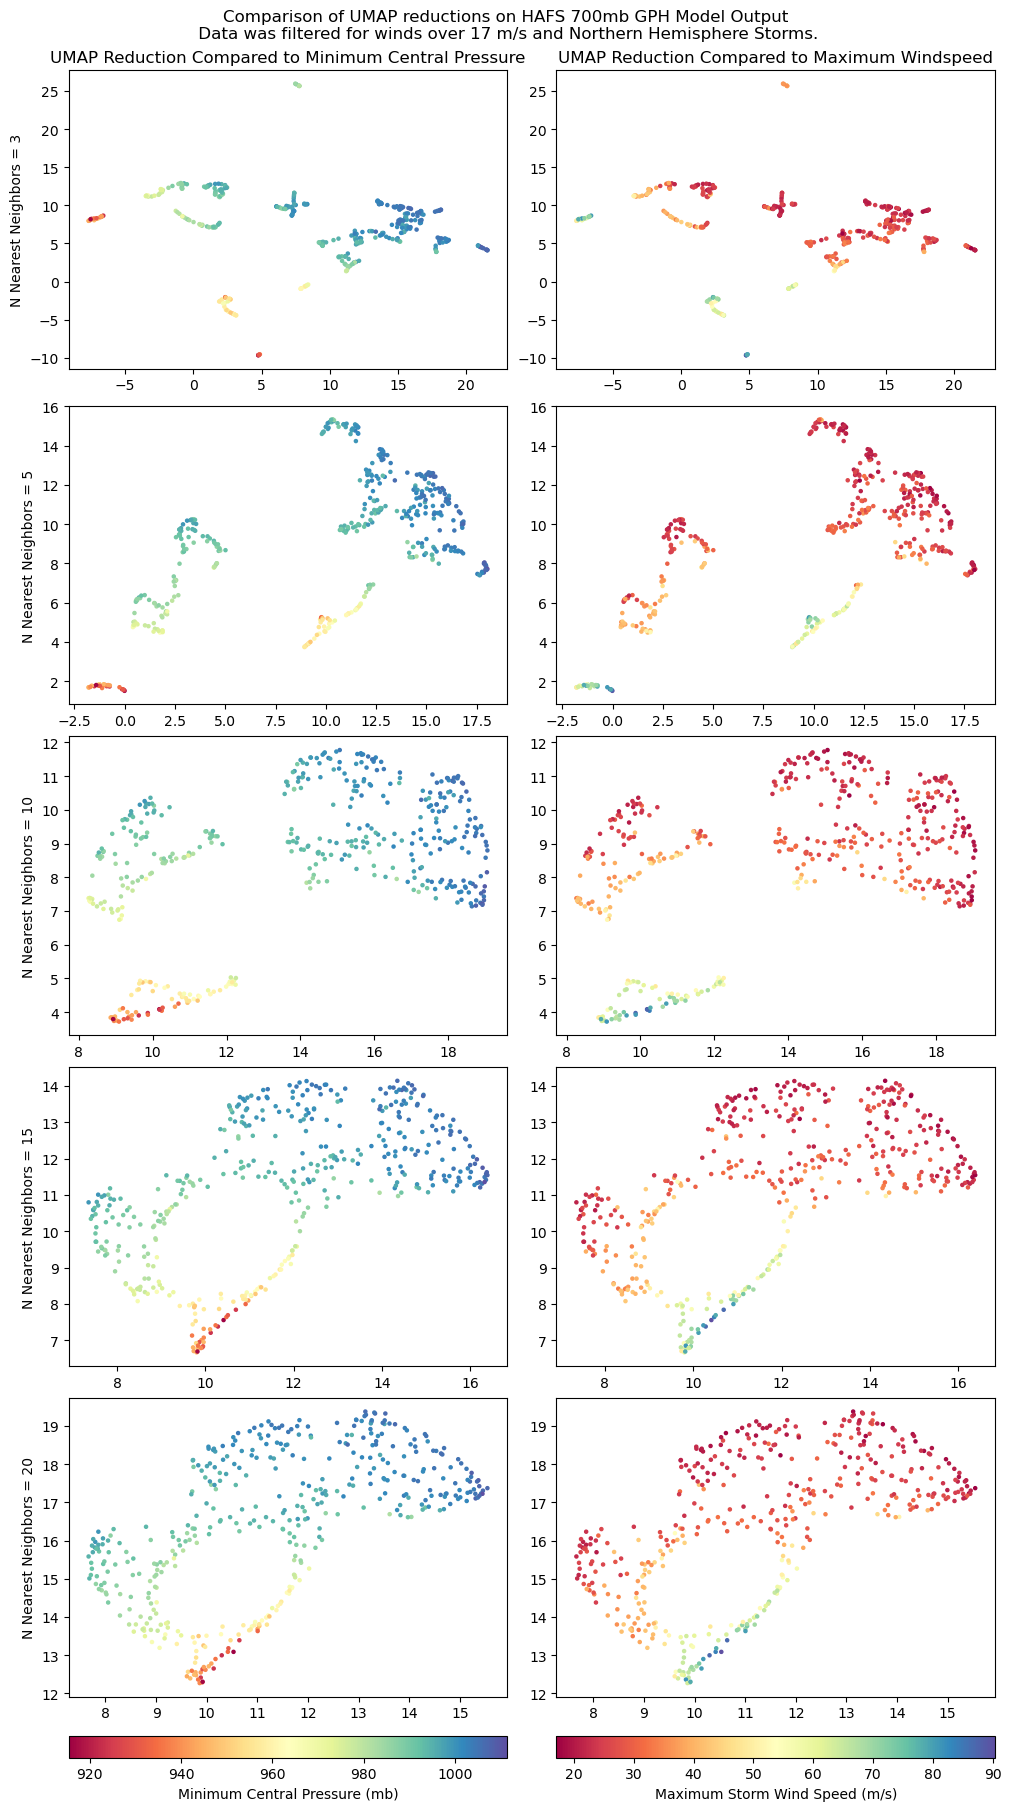

In [27]:
fig, ax = plt.subplots(nrows = 5, ncols = 2, constrained_layout = True, figsize = (10,18))

ax[0,0].scatter(embedding_GH700_n3[:,0], embedding_GH700_n3[:,1], c = mslp, cmap = 'Spectral', s = 5)
ax[0,0].set_ylabel('N Nearest Neighbors = 3')
ax[0,0].set_title('UMAP Reduction Compared to Minimum Central Pressure')

ax[1,0].scatter(embedding_GH700_n5[:,0], embedding_GH700_n5[:,1], c = mslp, cmap = 'Spectral', s = 5)
ax[1,0].set_ylabel('N Nearest Neighbors = 5')

ax[2,0].scatter(embedding_GH700_n10[:,0], embedding_GH700_n10[:,1], c = mslp, cmap = 'Spectral', s = 5)
ax[2,0].set_ylabel('N Nearest Neighbors = 10')

ax[3,0].scatter(embedding_GH700_n15[:,0], embedding_GH700_n15[:,1], c = mslp, cmap = 'Spectral', s = 5)
ax[3,0].set_ylabel('N Nearest Neighbors = 15')

mslp_im = ax[4,0].scatter(embedding_GH700_n20[:,0], embedding_GH700_n20[:,1], c = mslp, cmap = 'Spectral', s = 5)
ax[4,0].set_ylabel('N Nearest Neighbors = 20')
fig.colorbar(mslp_im, ax = ax[4,0], location = 'bottom', label = 'Minimum Central Pressure (mb)')

ax[0,1].scatter(embedding_GH700_n3[:,0], embedding_GH700_n3[:,1], c = max_winds, cmap = 'Spectral', s = 5)
ax[0,1].set_title('UMAP Reduction Compared to Maximum Windspeed')

ax[1,1].scatter(embedding_GH700_n5[:,0], embedding_GH700_n5[:,1], c = max_winds, cmap = 'Spectral', s = 5)

ax[2,1].scatter(embedding_GH700_n10[:,0], embedding_GH700_n10[:,1], c = max_winds, cmap = 'Spectral', s = 5)

ax[3,1].scatter(embedding_GH700_n15[:,0], embedding_GH700_n15[:,1], c = max_winds, cmap = 'Spectral', s = 5)

max_wind_im = ax[4,1].scatter(embedding_GH700_n20[:,0], embedding_GH700_n20[:,1], c = max_winds, cmap = 'Spectral', s = 5)
fig.colorbar(max_wind_im, ax = ax[4,1], location = 'bottom', label = 'Maximum Storm Wind Speed (m/s)')

fig.suptitle('Comparison of UMAP reductions on HAFS 700mb GPH Model Output' \
            '\n Data was filtered for winds over 17 m/s and Northern Hemisphere Storms.')


Text(0.5, 0.98, 'Comparison of UMAP reductions on HAFS 700mb GPH, T, and RH Model Output\n Data was filtered for winds over 17 m/s and Northern Hemisphere Storms.')

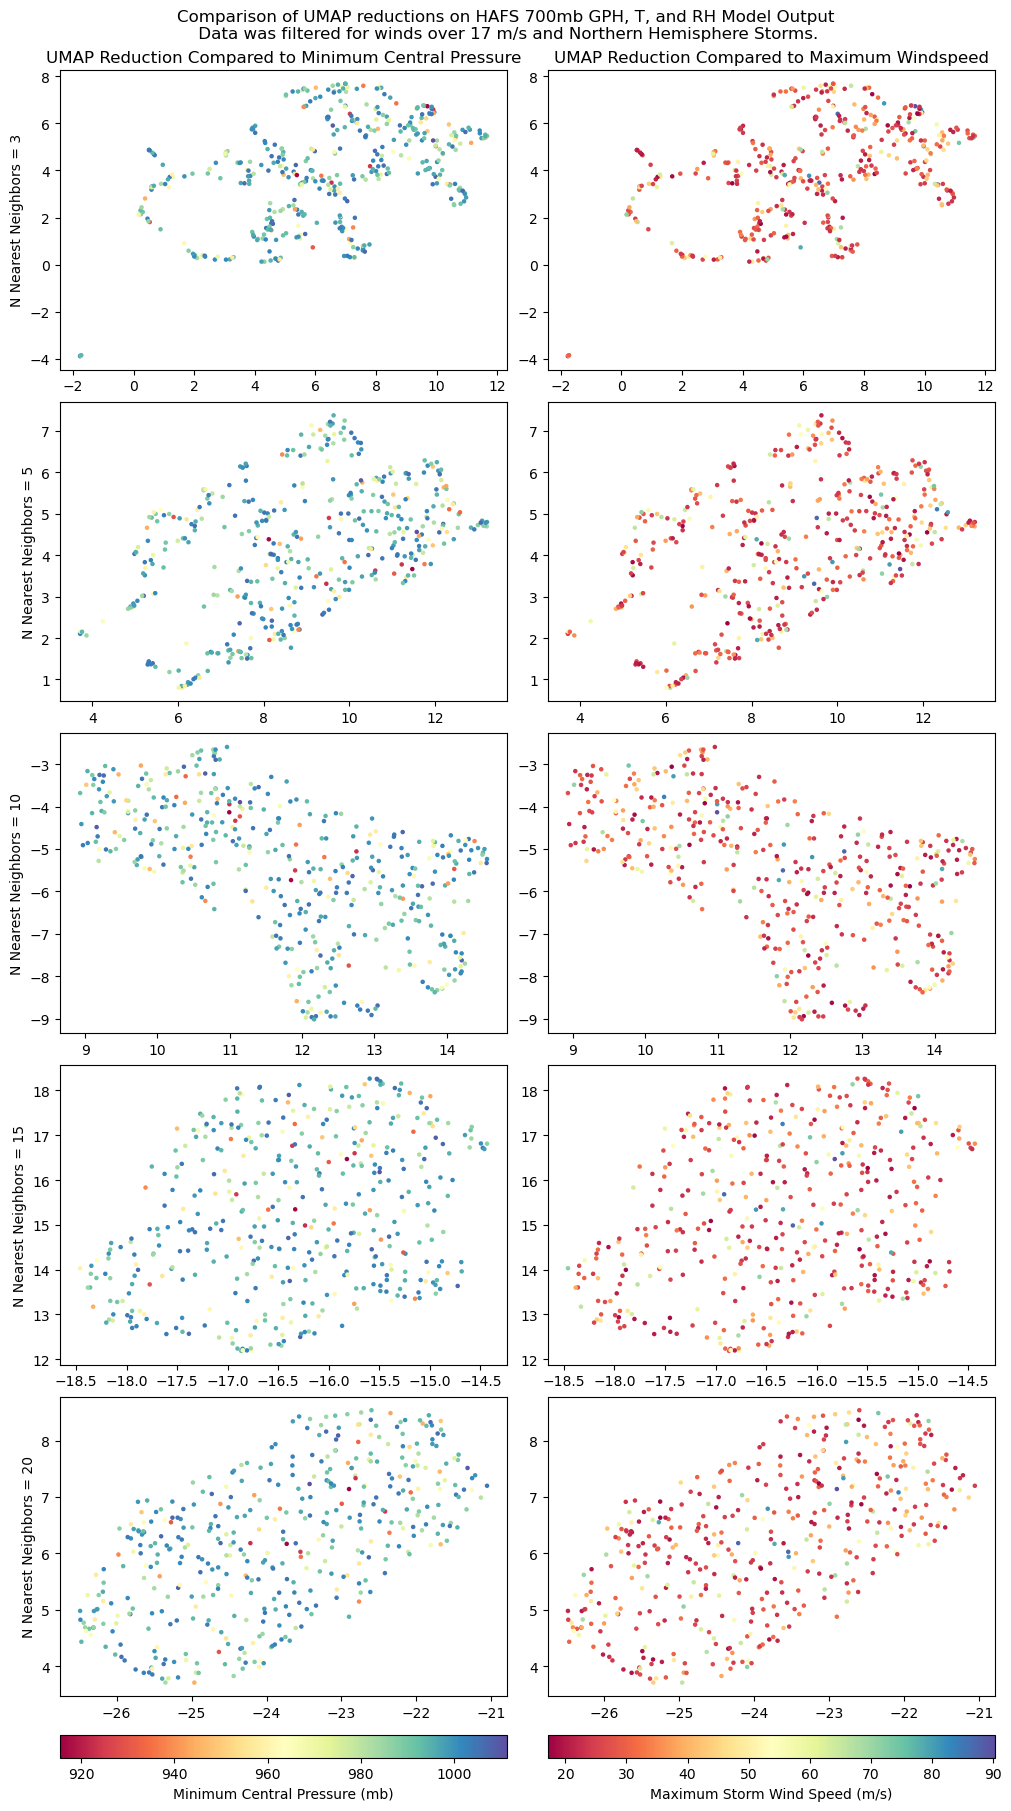

In [28]:
fig, ax = plt.subplots(nrows = 5, ncols = 2, constrained_layout = True, figsize = (10,18))

ax[0,0].scatter(embedding_Full700_n3[:,0], embedding_Full700_n3[:,1], c = mslp, cmap = 'Spectral', s = 5)
ax[0,0].set_ylabel('N Nearest Neighbors = 3')
ax[0,0].set_title('UMAP Reduction Compared to Minimum Central Pressure')

ax[1,0].scatter(embedding_Full700_n5[:,0], embedding_Full700_n5[:,1], c = mslp, cmap = 'Spectral', s = 5)
ax[1,0].set_ylabel('N Nearest Neighbors = 5')

ax[2,0].scatter(embedding_Full700_n10[:,0], embedding_Full700_n10[:,1], c = mslp, cmap = 'Spectral', s = 5)
ax[2,0].set_ylabel('N Nearest Neighbors = 10')

ax[3,0].scatter(embedding_Full700_n15[:,0], embedding_Full700_n15[:,1], c = mslp, cmap = 'Spectral', s = 5)
ax[3,0].set_ylabel('N Nearest Neighbors = 15')

mslp_im = ax[4,0].scatter(embedding_Full700_n20[:,0], embedding_Full700_n20[:,1], c = mslp, cmap = 'Spectral', s = 5)
ax[4,0].set_ylabel('N Nearest Neighbors = 20')
fig.colorbar(mslp_im, ax = ax[4,0], location = 'bottom', label = 'Minimum Central Pressure (mb)')

ax[0,1].scatter(embedding_Full700_n3[:,0], embedding_Full700_n3[:,1], c = max_winds, cmap = 'Spectral', s = 5)
ax[0,1].set_title('UMAP Reduction Compared to Maximum Windspeed')

ax[1,1].scatter(embedding_Full700_n5[:,0], embedding_Full700_n5[:,1], c = max_winds, cmap = 'Spectral', s = 5)

ax[2,1].scatter(embedding_Full700_n10[:,0], embedding_Full700_n10[:,1], c = max_winds, cmap = 'Spectral', s = 5)

ax[3,1].scatter(embedding_Full700_n15[:,0], embedding_Full700_n15[:,1], c = max_winds, cmap = 'Spectral', s = 5)

max_wind_im = ax[4,1].scatter(embedding_Full700_n20[:,0], embedding_Full700_n20[:,1], c = max_winds, cmap = 'Spectral', s = 5)
fig.colorbar(max_wind_im, ax = ax[4,1], location = 'bottom', label = 'Maximum Storm Wind Speed (m/s)')

fig.suptitle('Comparison of UMAP reductions on HAFS 700mb GPH, T, and RH Model Output' \
            '\n Data was filtered for winds over 17 m/s and Northern Hemisphere Storms.')